# Training log curves

Plot loss and KPI series from `training_log.json` for a run under `introducing_superpoint/runs/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent.parent))
sys.path.append(str(Path.cwd().parent))

import conf
from model_instance import ModelInstance, TrainingConfig

In [2]:
RUN_NAME = "smoke"
LOG_PATH = None

log_path = (
    ModelInstance(name=RUN_NAME, config=TrainingConfig(name=RUN_NAME)).log_path
    if LOG_PATH is None
    else conf.resolve(LOG_PATH)
)
instance = ModelInstance.load_log(log_path)
print(log_path)
print(f"epochs: {len(instance.epoch_logs)}")

/home/alexander.hallmann/Desktop/medical-image-registration/introducing_superpoint/runs/smoke/training_log.json
epochs: 25


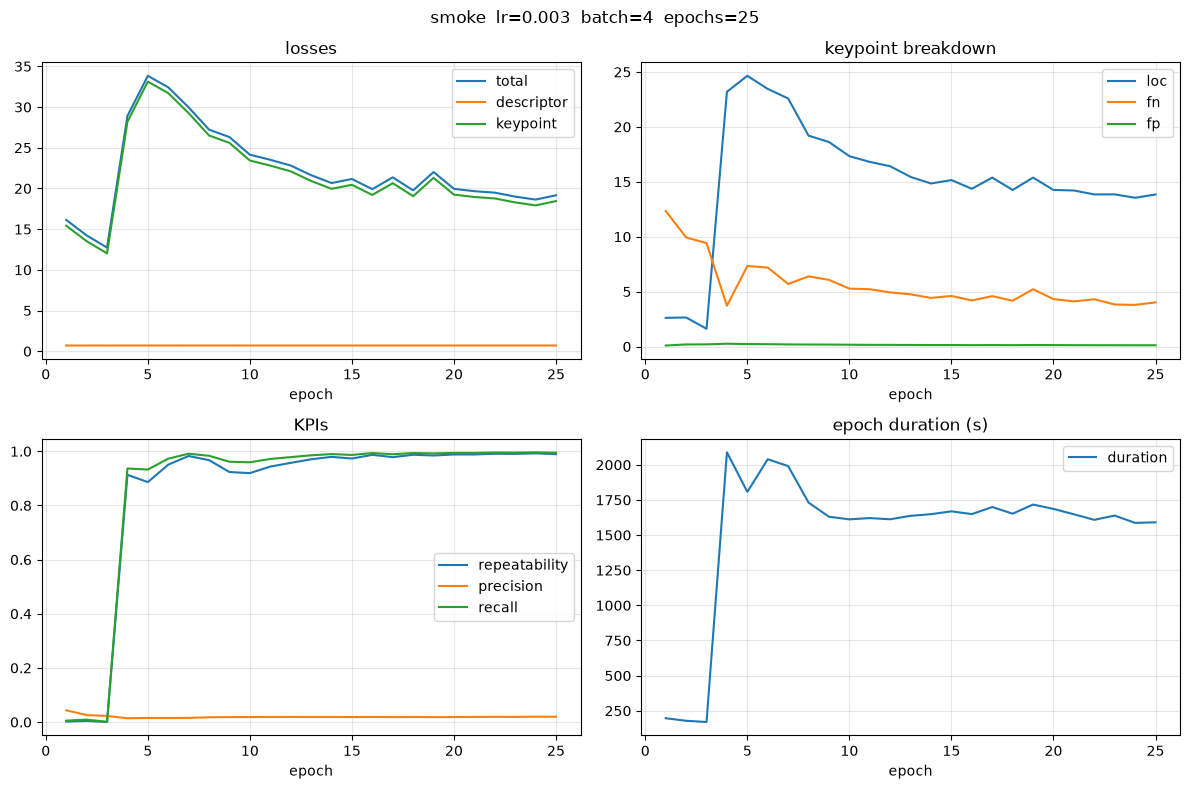

In [3]:
logs = instance.epoch_logs
if not logs:
    raise ValueError("no epoch logs to plot")

epochs = [entry.epoch for entry in logs]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cfg = instance.config

panels = [
    (axes[0, 0], "losses", [("total", "loss_total"), ("keypoint", "loss_keypoint")]),
    (axes[0, 1], "keypoint breakdown", [("loc", "loss_loc"), ("fn", "loss_fn"), ("fp", "loss_fp")]),
    (axes[1, 0], "KPIs", [("repeatability", "repeatability"), ("precision", "precision"), ("recall", "recall")]),
    (axes[1, 1], "descriptor loss", [("descriptor", "loss_descriptor")]),
]

for ax, title, fields in panels:
    for label, field in fields:
        ax.plot(epochs, [getattr(entry, field) for entry in logs], label=label)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"{instance.name}  lr={cfg.learning_rate}  batch={cfg.batch_size}  epochs={len(logs)}"
)
fig.tight_layout()
plt.show()